# Complete End-to-End NLP Pipeline


## Install libraries
Run only if required.


pip install nltk spacy textblob scikit-learn pandas numpy matplotlib
!python -m spacy download en_core_web_sm


In [1]:
!pip install nltk spacy textblob scikit-learn pandas numpy matplotlib

   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   ---- ----------------------------------- 1.8/15.2 MB 9.1 MB/s eta 0:00:02
   ----------- ---------------------------- 4.2/15.2 MB 10.2 MB/s eta 0:00:02
   ---------------- ----------------------- 6.3/15.2 MB 10.1 MB/s eta 0:00:01
   ---------------------- ----------------- 8.4/15.2 MB 10.1 MB/s eta 0:00:01
   --------------------------- ------------ 10.5/15.2 MB 10.1 MB/s eta 0:00:01
   -------------------------------- ------- 12.3/15.2 MB 10.0 MB/s eta 0:00:01
   ------------------------------------- -- 14.4/15.2 MB 10.0 MB/s eta 0:00:01
   ---------------------------------------  14.9/15.2 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 15.2/15.2 MB 8.4 MB/s  0:00:01
   ---------------------------------------- 0.0/674.2 kB ? eta -:--:--
   ---------------------------------------- 674.2/674.2 kB 6.9 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------

In [2]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ------ --------------------------------- 2.1/12.8 MB 11.2 MB/s eta 0:00:01
     ------------- -------------------------- 4.5/12.8 MB 11.7 MB/s eta 0:00:01
     --------------------- ------------------ 6.8/12.8 MB 11.3 MB/s eta 0:00:01
     ----------------------------- ---------- 9.4/12.8 MB 11.6 MB/s eta 0:00:01
     ----------------------------------- --- 11.8/12.8 MB 11.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 10.6 MB/s  0:00:01
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [30]:
import re, string, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk, spacy
from collections import Counter
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.util import ngrams
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
print(nltk.__version__, spacy.__version__)

3.10.0 3.8.16


In [31]:
for r in ["punkt","punkt_tab","stopwords","wordnet","omw-1.4","averaged_perceptron_tagger","averaged_perceptron_tagger_eng"]:
    nltk.download(r, quiet=True)
try:
    nlp=spacy.load("en_core_web_sm")
    print("spaCy model loaded")
except OSError:
    nlp=None
    print("Install model with: !python -m spacy download en_core_web_sm")

spaCy model loaded


## Create sample data
We use customer reviews for a binary sentiment-classification example: `1=positive`, `0=negative`.

In [33]:
data={"review":[
"The product is excellent and works perfectly.","I loved the quality and fast delivery.","Amazing experience and fantastic service.","The support team was friendly and helpful.","I am very happy with this purchase.","The product is useful reliable and easy to use.","Excellent quality and great customer service.","The product arrived quickly and works well.","I highly recommend this product.","The price is reasonable and the quality is good.",
"I hated this product and want a refund.","The quality is terrible and it stopped working.","Very disappointing experience.","The delivery was late and the package was damaged.","The service was rude and unhelpful.","This product is poor and not worth the money.","I am unhappy with this purchase.","The product failed after one day.","Terrible customer support and slow response.","I would not recommend this product."],
"sentiment":[1]*10+[0]*10}
df=pd.DataFrame(data); df

,review,sentiment
0,The product is excellent and works perfectly.,1
1,I loved the quality and fast delivery.,1
2,Amazing experience and fantastic service.,1
3,The support team was friendly and helpful.,1
4,I am very happy with this purchase.,1
5,The product is useful reliable and easy to use.,1
6,Excellent quality and great customer service.,1
7,The product arrived quickly and works well.,1
8,I highly recommend this product.,1
9,The price is reasonable and the quality is good.,1


## Explore the data
Check shape, classes, missing values and duplicates before NLP processing.

In [34]:
print("Shape:",df.shape)
print("\nClasses:",df.sentiment.value_counts())
print("\nMissing values:",df.isnull().sum())
print("\nDuplicates:",df.duplicated().sum())

Shape: (20, 2)

Classes: sentiment
1    10
0    10
Name: count, dtype: int64

Missing values: review       0
sentiment    0
dtype: int64

Duplicates: 0


## Text cleaning
Typical operations include lowercasing, URL/HTML removal, punctuation handling and whitespace normalization. Do not remove information blindly; the correct cleaning depends on the task.

In [35]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"https?://\S+|www\.\S+","",text)
    text=re.sub(r"<.*?>","",text)
    text=text.translate(str.maketrans("","",string.punctuation))
    text=re.sub(r"\d+","",text)
    return re.sub(r"\s+"," ",text).strip()
df["clean_text"]=df.review.apply(clean_text)
df[["review","clean_text"]].head()

,review,clean_text
0,The product is excellent and works perfectly.,the product is excellent and works perfectly
1,I loved the quality and fast delivery.,i loved the quality and fast delivery
2,Amazing experience and fantastic service.,amazing experience and fantastic service
3,The support team was friendly and helpful.,the support team was friendly and helpful
4,I am very happy with this purchase.,i am very happy with this purchase


## Stopword removal
Stopwords are common words such as `the`, `is`, `and`. They can reduce vocabulary size, but words such as **not** may be important for sentiment, so stopword removal should be task-dependent.

In [36]:
stop_words=set(stopwords.words("english"))
tokens=word_tokenize(df.loc[0,"clean_text"])
print("Before:",tokens)
print("After:",[t for t in tokens if t not in stop_words])

Before: ['the', 'product', 'is', 'excellent', 'and', 'works', 'perfectly']
After: ['product', 'excellent', 'works', 'perfectly']


## Build normalized text
For the classifier we lowercase, clean, tokenize, remove selected stopwords, retain alphabetic tokens, and lemmatize with spaCy.

In [37]:
def preprocess(text):
    text=clean_text(text)
    tokens=[t for t in word_tokenize(text) if t.isalpha() and t not in stop_words]
    if nlp:
        d=nlp(" ".join(tokens))
        tokens=[t.lemma_ for t in d if t.is_alpha and t.lemma_ not in stop_words]
    return " ".join(tokens)
df["processed_text"]=df.review.apply(preprocess)
df[["review","processed_text"]].head()

,review,processed_text
0,The product is excellent and works perfectly.,product excellent work perfectly
1,I loved the quality and fast delivery.,love quality fast delivery
2,Amazing experience and fantastic service.,amazing experience fantastic service
3,The support team was friendly and helpful.,support team friendly helpful
4,I am very happy with this purchase.,happy purchase


In [14]:
s="The intelligent system analyzes customer feedback quickly."
print("NLTK:")
for w,t in pos_tag(word_tokenize(s)): print(f"{w:15} {t}")
if nlp:
    d=nlp(s)
    display(pd.DataFrame({"Token":[x.text for x in d],"POS":[x.pos_ for x in d],"Tag":[x.tag_ for x in d],"Lemma":[x.lemma_ for x in d]}))

NLTK:
The             DT
intelligent     NN
system          NN
analyzes        VBZ
customer        NN
feedback        NN
quickly         RB
.               .


,Token,POS,Tag,Lemma
0,The,DET,DT,the
1,intelligent,ADJ,JJ,intelligent
2,system,NOUN,NN,system
3,analyzes,VERB,VBZ,analyze
4,customer,NOUN,NN,customer
5,feedback,NOUN,NN,feedback
6,quickly,ADV,RB,quickly
7,.,PUNCT,.,.


##  Word frequency analysis
Frequency counts provide a basic view of vocabulary and common terms.

,Word,Frequency
0,product,8
1,quality,4
2,work,3
3,service,3
4,excellent,2
5,delivery,2
6,experience,2
7,support,2
8,purchase,2
9,customer,2


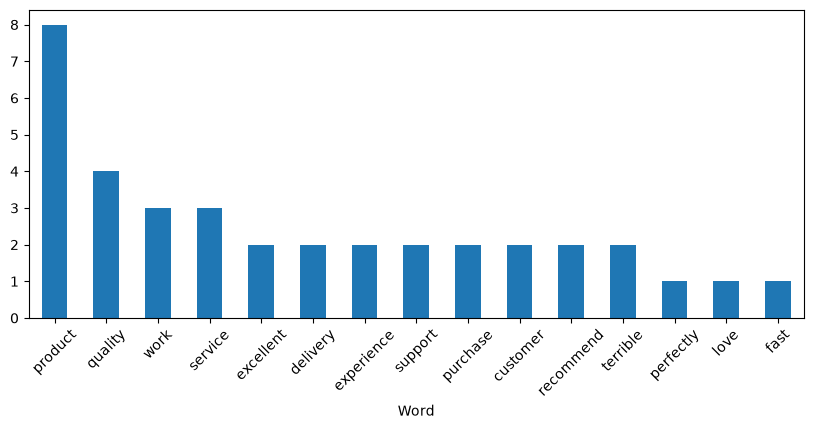

In [38]:
all_tokens=" ".join(df.processed_text).split()
freq=pd.DataFrame(Counter(all_tokens).most_common(15),columns=["Word","Frequency"])
display(freq)
freq.plot(x="Word",y="Frequency",kind="bar",legend=False,figsize=(10,4)); plt.xticks(rotation=45); plt.show()

## Bag of Words
BoW represents documents by word counts and ignores word order.

In [39]:
bow=CountVectorizer()
X_bow=bow.fit_transform(df.processed_text)
print("Matrix shape:",X_bow.shape)
bow_df=pd.DataFrame(X_bow.toarray(),columns=bow.get_feature_names_out())
display(bow_df.head())

Matrix shape: (20, 53)


,amazing,arrive,customer,damage,day,delivery,disappointing,easy,excellent,experience,...,terrible,unhappy,unhelpful,use,useful,want,well,work,worth,would
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## TF-IDF
TF-IDF weights terms using their frequency in a document and rarity across the corpus. It often works well for classical text classification.

In [40]:
tfidf=TfidfVectorizer()
X_tfidf=tfidf.fit_transform(df.processed_text)
print("Matrix shape:",X_tfidf.shape)
tfidf_df=pd.DataFrame(X_tfidf.toarray(),columns=tfidf.get_feature_names_out())
display(tfidf_df.head())

Matrix shape: (20, 53)


,amazing,arrive,customer,damage,day,delivery,disappointing,easy,excellent,experience,...,terrible,unhappy,unhelpful,use,useful,want,well,work,worth,would
0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.534396,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.482209,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.483838,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.542183,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.476587,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [41]:
i=0
top=tfidf_df.iloc[i].sort_values(ascending=False).head(10)
print("Document:",df.loc[i,"review"])
display(top.to_frame("TF-IDF"))

Document: The product is excellent and works perfectly.


,TF-IDF
perfectly,0.607948
excellent,0.534396
work,0.482209
product,0.335104
arrive,0.000000
day,0.000000
delivery,0.000000
disappointing,0.000000
easy,0.000000
experience,0.000000


## TextBlob sentiment analysis
TextBlob provides a simple lexicon-based sentiment interface. Polarity ranges roughly from -1 to +1.

In [42]:
for s in ["I love this excellent product!","This product is terrible.","The product is okay."]:
    b=TextBlob(s); print(s,"| polarity=",round(b.sentiment.polarity,3),"subjectivity=",round(b.sentiment.subjectivity,3))

I love this excellent product! | polarity= 0.75 subjectivity= 0.8
This product is terrible. | polarity= -1.0 subjectivity= 1.0
The product is okay. | polarity= 0.5 subjectivity= 0.5


## Train/test split
Separate data before fitting the final model so that the test set remains unseen during training.

In [43]:
X_train,X_test,y_train,y_test=train_test_split(df.processed_text,df.sentiment,test_size=.25,random_state=42,stratify=df.sentiment)
print(len(X_train),len(X_test))

15 5


## End-to-end TF-IDF + Logistic Regression pipeline
The scikit-learn Pipeline guarantees that TF-IDF transformation learned from training data is applied consistently to test/new data.

In [44]:
model=Pipeline([("tfidf",TfidfVectorizer(ngram_range=(1,2))), ("classifier",LogisticRegression(max_iter=1000))])
model.fit(X_train,y_train)
print("Training complete")

Training complete


## Evaluate the classifier

In [45]:
pred=model.predict(X_test)
print("Accuracy:",round(accuracy_score(y_test,pred),3))
print(classification_report(y_test,pred,target_names=["Negative","Positive"]))

Accuracy: 0.2
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.25      0.50      0.33         2

    accuracy                           0.20         5
   macro avg       0.12      0.25      0.17         5
weighted avg       0.10      0.20      0.13         5



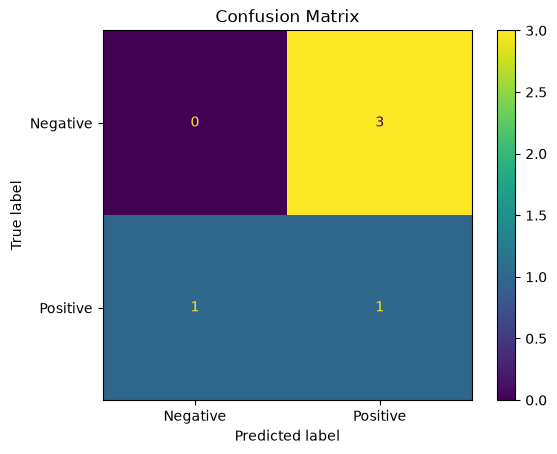

In [46]:
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm,display_labels=["Negative","Positive"]).plot()
plt.title("Confusion Matrix"); plt.show()

## Predict new text
The trained pipeline takes normalized text and returns the predicted sentiment.

In [47]:
new_reviews=["The product is excellent and I am very happy.","The service was terrible and disappointing.","Good quality and fast delivery.","I regret buying this poor product."]
pred=model.predict([preprocess(x) for x in new_reviews])
probs=model.predict_proba([preprocess(x) for x in new_reviews])
results=pd.DataFrame({"Review":new_reviews,"Prediction":["Positive" if p else "Negative" for p in pred],"Negative_Prob":probs[:,0].round(3),"Positive_Prob":probs[:,1].round(3)})
results

,Review,Prediction,Negative_Prob,Positive_Prob
0,The product is excellent and I am very happy.,Positive,0.408,0.592
1,The service was terrible and disappointing.,Negative,0.515,0.485
2,Good quality and fast delivery.,Positive,0.379,0.621
3,I regret buying this poor product.,Negative,0.509,0.491
